# Esercizio 05 — Campionamento Metropolis degli orbitali dell'atomo di idrogeno

In questo esercizio usiamo l'algoritmo di Metropolis per campionare la densità di probabilità elettronica dell'atomo di idrogeno e stimare il valore medio della distanza dell'elettrone dal nucleo.

Le distanze sono espresse in unità del raggio di Bohr, quindi nel codice poniamo $a_0 = 1$.


## Richiesta dell'esercizio

La consegna richiede di campionare in coordinate cartesiane le distribuzioni di probabilità associate agli stati $1s$ e $2p$ dell'atomo di idrogeno e di stimare, tramite data blocking, i valori medi

$$
\langle r \rangle_{1s} = \frac{3}{2}a_0,
\qquad
\langle r \rangle_{2p} = 5a_0.
$$

Bisogna inoltre scegliere il passo della proposta in modo da avere un'accettazione circa del $50\%$, confrontare proposta uniforme e proposta gaussiana, visualizzare i punti campionati nello spazio e discutere cosa accade se la catena parte molto lontano dall'origine.


## Densità di probabilità campionate

Per lo stato fondamentale $1s$ la funzione d'onda è sfericamente simmetrica. In unità $a_0 = 1$, la densità di probabilità è

$$
|\Psi_{1,0,0}(x,y,z)|^2 = \frac{1}{\pi} e^{-2r},
$$

con

$$
r = \sqrt{x^2+y^2+z^2}.
$$

Per lo stato eccitato $2p$, scegliendo l'orbitale con $m=0$, si ha invece

$$
|\Psi_{2,1,0}(x,y,z)|^2 = \frac{1}{32\pi} z^2 e^{-r}.
$$

Il fattore $z^2$ produce due lobi lungo l'asse $z$ e annulla la probabilità sul piano nodale $z=0$. Per questo motivo, per il $2p$, conviene partire da un punto già compatibile con la struttura dell'orbitale, ad esempio $(0,0,2)$, e non dall'origine.


## Algoritmo di Metropolis

Il Metropolis è un metodo Markov Chain Monte Carlo. L'idea non è estrarre direttamente punti indipendenti dalla distribuzione target $p(\mathbf{x})=|\Psi(\mathbf{x})|^2$, ma costruire una catena di configurazioni

$$
\mathbf{x}_0,\mathbf{x}_1,\mathbf{x}_2,\ldots
$$

che, dopo una fase iniziale di equilibrazione, visita le diverse regioni dello spazio con frequenza proporzionale alla densità di probabilità desiderata.

A ogni passo, partendo dalla posizione corrente $\mathbf{x}$, viene proposta una nuova posizione $\mathbf{x}'$ secondo una distribuzione di transizione $T(\mathbf{x}'|\mathbf{x})$. In questo esercizio sono state usate due proposte simmetriche:

$$
\mathbf{x}' = \mathbf{x} + \Delta \mathbf{x}.
$$

Nel primo caso le componenti $\Delta x$, $\Delta y$ e $\Delta z$ sono estratte uniformemente nell'intervallo $[-\delta,\delta]$; nel secondo caso sono estratte da una distribuzione gaussiana con media nulla e deviazione standard $\sigma$.

La probabilità generale di accettazione della mossa è

$$
A(\mathbf{x}'|\mathbf{x}) =
\min\left[1,
\frac{T(\mathbf{x}|\mathbf{x}')p(\mathbf{x}')}
{T(\mathbf{x}'|\mathbf{x})p(\mathbf{x})}
\right].
$$

Nel nostro caso le due distribuzioni di proposta sono simmetriche, cioè la probabilità di proporre $\mathbf{x}'$ partendo da $\mathbf{x}$ è uguale alla probabilità di proporre $\mathbf{x}$ partendo da $\mathbf{x}'$:

$$
T(\mathbf{x}'|\mathbf{x}) = T(\mathbf{x}|\mathbf{x}').
$$

Per questo motivo il rapporto tra le probabilità di transizione si semplifica e la probabilità di accettazione diventa

$$
A(\mathbf{x}'|\mathbf{x}) =
\min\left(1,\frac{p(\mathbf{x}')}{p(\mathbf{x})}\right).
$$

Se la densità nel punto proposto è maggiore di quella nel punto corrente, la mossa viene sempre accettata; se invece è minore, la mossa può comunque essere accettata con probabilità pari al rapporto $p(\mathbf{x}')/p(\mathbf{x})$. Questo permette alla catena di esplorare anche regioni meno probabili, evitando di rimanere bloccata solo vicino ai massimi della distribuzione.

Se la mossa è accettata, la nuova configurazione diventa $\mathbf{x}'$; se è rifiutata, la configurazione successiva resta uguale a quella precedente. La scelta della probabilità di accettazione è costruita in modo da soddisfare il bilancio dettagliato, cioè da bilanciare, all'equilibrio, il flusso di probabilità tra due configurazioni qualsiasi. In questo modo la distribuzione target $p(\mathbf{x})$ risulta stazionaria per la catena di Markov.

Un punto pratico importante è che i punti generati dal Metropolis non sono indipendenti: ogni configurazione nasce dalla precedente. Per questo motivo si esegue una fase iniziale di equilibrazione e si stima l'incertezza statistica tramite data blocking, scegliendo blocchi abbastanza lunghi da ridurre l'effetto delle correlazioni tra configurazioni successive.


## Implementazione C++

Nel codice C++ il campionamento viene eseguito direttamente nello spazio cartesiano tridimensionale. A ogni passo l’algoritmo propone una nuova posizione $\mathbf{x}'=(x',y',z')$ a partire dalla posizione corrente $\mathbf{x}=(x,y,z)$, usando alternativamente una transizione uniforme o gaussiana. Poiché entrambe le proposte sono simmetriche, il criterio di accettazione di Metropolis dipende solo dal rapporto tra le densità di probabilità nei due punti.

Le densità vengono calcolate direttamente dalle funzioni d’onda degli orbitali. Nel codice sono mantenute anche le costanti di normalizzazione, anche se nel rapporto Metropolis si cancellano, perché rendono più esplicito il collegamento tra implementazione numerica e distribuzione fisica campionata.

La simulazione è organizzata in blocchi. In ogni blocco viene calcolata la media di $r=\sqrt{x^2+y^2+z^2}$; le medie di blocco vengono poi usate per costruire la stima progressiva di $\langle r\rangle$ e la relativa incertezza statistica tramite data blocking. Prima della misura viene eseguita una fase di equilibrazione, in modo che la catena perda memoria della configurazione iniziale.

```cpp
struct Position {
   double x;
   double y;
   double z;

   double norm() const {
      return sqrt(x*x + y*y + z*z);
   }
};

double probability_density(Position p, State state) {
   double r = p.norm();

   if (state == State::Ground1s) {
      return (1.0 / M_PI) * exp(-2.0 * r);
   }

   if (state == State::Excited2p) {
      return (1.0 / (32.0 * M_PI)) * p.z * p.z * exp(-r);
   }

   return 0.0;
}
```

```cpp
bool metropolis_step(Position &p, Random &rnd, State state, Proposal proposal, double step) {
   Position p_new = propose(p, rnd, proposal, step);

   double p_old = probability_density(p, state);
   double p_trial = probability_density(p_new, state);

   if (p_old <= 0.0) {
      if (p_trial > 0.0) {
         p = p_new;
         return true;
      } else {
         return false;
      }
   }

   double acceptance_probability = min(1.0, p_trial / p_old);

   if (rnd.Rannyu() < acceptance_probability) {
      p = p_new;
      return true;
   }

   return false;
}
```

## Analisi dei dati

I file prodotti dal codice C++ sono letti dalla cartella `results/`. La simulazione principale usa $100$ blocchi da $10^4$ passi ciascuno, quindi $M = 10^6$ passi Metropolis per ogni combinazione stato-proposta.

Le condizioni iniziali usate per la simulazione principale sono scelte in modo da partire già in una regione ragionevole della distribuzione: per lo stato $1s$ si parte da $(0.1,0.1,0.1)$, vicino all’origine, mentre per lo stato $2p$ si parte da $(0,0,2)$, cioè lungo l’asse dei due lobi. Questa seconda scelta evita di iniziare sul piano nodale $z=0$, dove la densità $|\Psi_{2,1,0}|^2 \propto z^2 e^{-r}$ si annulla.

Prima della misura viene eseguita una fase di equilibrazione, così che le medie a blocchi siano calcolate quando la catena ha già raggiunto la regione tipica della distribuzione bersaglio. Per gli scatter plot 3D viene poi usato solo un sottoinsieme dei punti salvati: non serve disegnare ogni punto della catena, ma è utile visualizzare la forma spaziale della distribuzione campionata.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 1.6,
    "axes.grid": True,
    "grid.alpha": 0.30,
})

possible_results_dirs = [Path("results"), Path("../results")]
RESULTS = next((path for path in possible_results_dirs if path.exists()), Path("results"))

In [2]:
def read_blocks(filename):
    path = RESULTS / filename
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")

    data = pd.read_csv(path, sep=r"\s+", comment="#", header=None)
    data.columns = ["block", "block_average", "progressive_average", "error", "acceptance"]

    return data


def read_trajectory(filename):
    path = RESULTS / filename
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")

    data = pd.read_csv(path, sep=r"\s+", comment="#", header=None)
    data.columns = ["x", "y", "z"]
    return data


def read_equilibration(filename):
    path = RESULTS / filename
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")

    data = pd.read_csv(path, sep=r"\s+", comment="#", header=None)
    data.columns = ["step", "r", "x", "y", "z"]
    return data


def format_value_error(value, error):
    return f"{value:.5f} ± {error:.5f}"

In [3]:
# File prodotti dal codice C++ per le quattro simulazioni
block_files = {
    ("1s", "Uniforme"): "metropolis_1s_uniform.txt",
    ("1s", "Gaussiana"): "metropolis_1s_gaussian.txt",
    ("2p", "Uniforme"): "metropolis_2p_uniform.txt",
    ("2p", "Gaussiana"): "metropolis_2p_gaussian.txt",
}

# Parametri scelti per le proposte Metropolis. Passo per la uniforme, sigma per la gaussiana.
parameters = {
    ("1s", "Uniforme"): r"$\delta = 1.20$",
    ("2p", "Uniforme"): r"$\delta = 3.00$",
    ("1s", "Gaussiana"): r"$\sigma = 0.75$",
    ("2p", "Gaussiana"): r"$\sigma = 1.85$",
}

# Valori teorici attesi, in unità di raggio di Bohr.
theory = {"1s": 1.5, "2p": 5.0}

# Lettura dei dati a blocchi.
block_data = {key: read_blocks(filename) for key, filename in block_files.items()}

# Costruzione di una tabella riassuntiva con il risultato finale di ciascuna simulazione.
summary_rows = []

for (state, proposal), data in block_data.items():
    final_value = data["progressive_average"].iloc[-1]
    final_error = data["error"].iloc[-1]
    exact_value = theory[state]
    acceptance_percent = 100 * data["acceptance"].mean()

    summary_rows.append({
        "Stato": state,
        "Proposta": proposal,
        "Parametro": parameters[(state, proposal)],
        r"$\langle r \rangle$ finale": format_value_error(final_value, final_error),
        "Valore teorico": exact_value,
        "Accettazione": f"{acceptance_percent:.1f}%" if not np.isnan(acceptance_percent) else "n.d.",
    })

summary = pd.DataFrame(summary_rows)
display(summary)

,Stato,Proposta,Parametro,$\langle r \rangle$ finale,Valore teorico,Accettazione
0,1s,Uniforme,$\delta = 1.20$,1.50082 ± 0.00395,1.5,50.8%
1,1s,Gaussiana,$\sigma = 0.75$,1.49705 ± 0.00443,1.5,50.5%
2,2p,Uniforme,$\delta = 3.00$,5.00762 ± 0.01137,5.0,49.8%
3,2p,Gaussiana,$\sigma = 1.85$,4.98915 ± 0.00965,5.0,50.4%


La tabella riassume direttamente anche l'accettazione. I valori vicini al $50\%$ indicano che il passo scelto è un buon compromesso: abbastanza grande da esplorare lo spazio, ma non così grande da produrre troppi rifiuti.


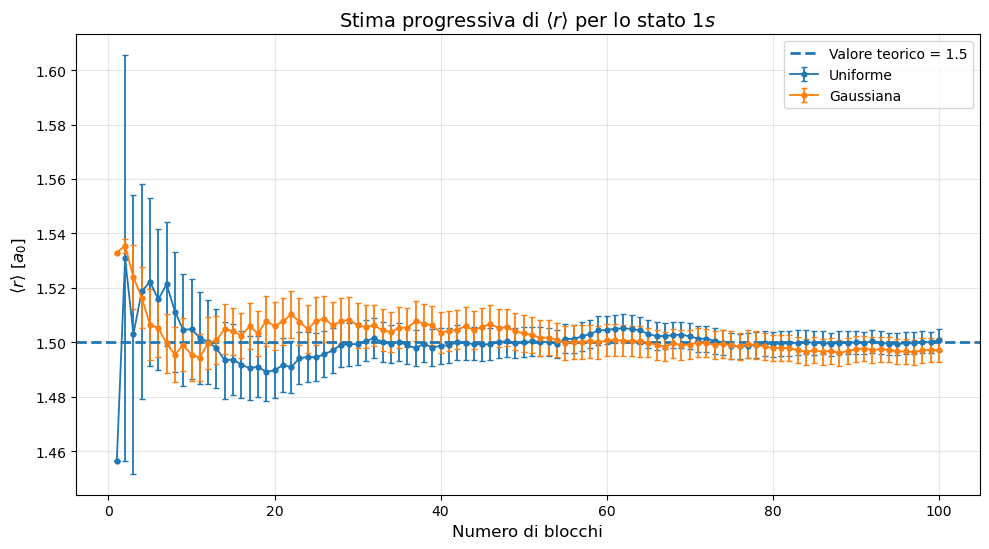

In [4]:
def plot_estimates(state, exact_value, title):
    fig, ax = plt.subplots(figsize=(10, 5.6))

    for proposal in ["Uniforme", "Gaussiana"]:
        data = block_data[(state, proposal)]
        ax.errorbar(
            data["block"],
            data["progressive_average"],
            yerr=data["error"],
            marker="o",
            markersize=3.5,
            capsize=2,
            linewidth=1.3,
            label=proposal,
        )

    ax.axhline(exact_value, linestyle="--", linewidth=2.0, label=f"Valore teorico = {exact_value}")
    ax.set_title(title)
    ax.set_xlabel("Numero di blocchi")
    ax.set_ylabel(r"$\langle r \rangle$ [$a_0$]")
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

plot_estimates("1s", 1.5, r"Stima progressiva di $\langle r \rangle$ per lo stato $1s$")

Per lo stato $1s$ entrambe le proposte convergono al valore teorico $\langle r \rangle_{1s}=1.5a_0$. La distribuzione è isotropa e concentrata vicino al nucleo, quindi la convergenza risulta piuttosto stabile.


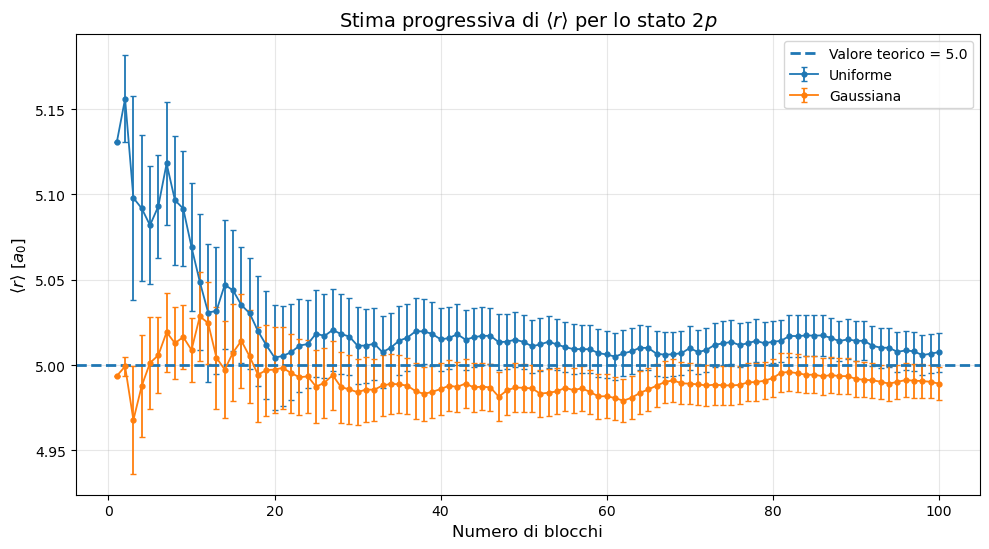

In [5]:
plot_estimates("2p", 5.0, r"Stima progressiva di $\langle r \rangle$ per lo stato $2p$")

Per lo stato $2p$ il valore teorico è $\langle r \rangle_{2p}=5a_0$. La distribuzione è più estesa e non sfericamente simmetrica; il piano nodale in $z=0$ rende naturale partire da un punto come $(0,0,2)$ prima dell'equilibrazione.


## Configurazioni campionate nello spazio

Gli scatter plot 3D permettono di controllare qualitativamente la forma delle distribuzioni campionate. La vista è scelta con un'inclinazione bassa, in modo da vedere meglio la separazione dei due lobi dello stato $2p$ lungo l'asse $z$.


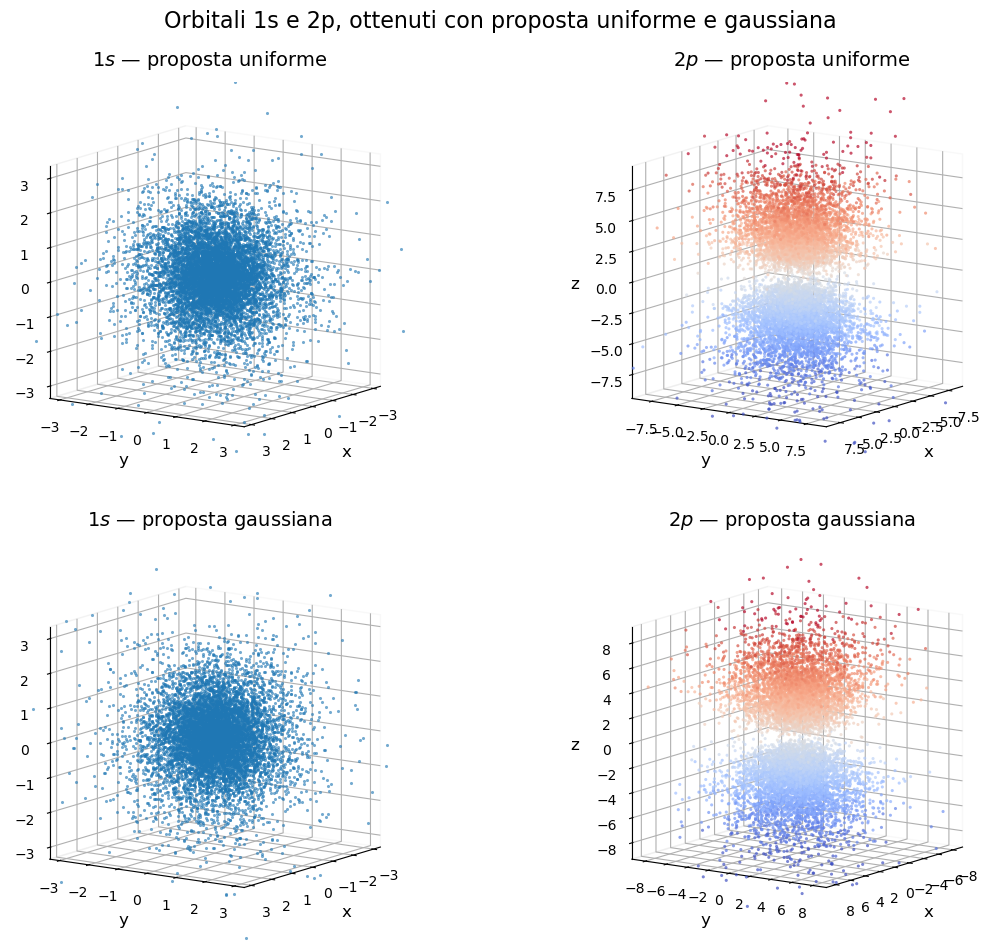

In [6]:
trajectory_files = {
    ("1s", "Uniforme"): "trajectory_1s_uniform.txt",
    ("1s", "Gaussiana"): "trajectory_1s_gaussian.txt",
    ("2p", "Uniforme"): "trajectory_2p_uniform.txt",
    ("2p", "Gaussiana"): "trajectory_2p_gaussian.txt",
}

trajectory_data = {key: read_trajectory(filename) for key, filename in trajectory_files.items()}


def sample_for_plot(data, max_points=9000):
    if len(data) <= max_points:
        return data.copy()
    return data.sample(max_points, random_state=7).copy()


def symmetric_limit(data, quantile=0.995):
    values = np.concatenate([
        data["x"].to_numpy(),
        data["y"].to_numpy(),
        data["z"].to_numpy()
    ])
    limit = np.quantile(np.abs(values), quantile)
    return max(limit, 1.0)


def polish_3d_axes(ax, data, title, elev=12, azim=35):
    limit = symmetric_limit(data)

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1))

    ax.view_init(elev=elev, azim=azim)
    ax.set_proj_type("ortho")

    ax.set_title(title, pad=12)
    ax.set_xlabel("x", labelpad=5)
    ax.set_ylabel("y", labelpad=5)
    ax.set_zlabel("z", labelpad=5)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.grid(alpha=0.25)


fig = plt.figure(figsize=(13, 10))

plot_order = [
    ("1s", "Uniforme"),
    ("2p", "Uniforme"),
    ("1s", "Gaussiana"),
    ("2p", "Gaussiana"),
]

titles = {
    ("1s", "Uniforme"): r"$1s$ — proposta uniforme",
    ("2p", "Uniforme"): r"$2p$ — proposta uniforme",
    ("1s", "Gaussiana"): r"$1s$ — proposta gaussiana",
    ("2p", "Gaussiana"): r"$2p$ — proposta gaussiana",
}

for i, key in enumerate(plot_order, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    data = sample_for_plot(trajectory_data[key])
    limit = symmetric_limit(data)

    if key[0] == "1s":
        ax.scatter(
            data["x"], data["y"], data["z"],
            s=5,
            alpha=0.62,
            linewidths=0,
            depthshade=False,
        )
    else:
        ax.scatter(
            data["x"], data["y"], data["z"],
            c=data["z"],
            cmap="coolwarm",
            vmin=-limit,
            vmax=limit,
            s=5,
            alpha=0.68,
            linewidths=0,
            depthshade=False,
        )

    polish_3d_axes(ax, data, titles[key], elev=12, azim=35)
    
fig.suptitle(r"Orbitali 1s e 2p, ottenuti con proposta uniforme e gaussiana", fontsize=16, y=0.96)
fig.tight_layout(pad=2.0)
plt.show()

Le configurazioni campionate mostrano la forma attesa delle due distribuzioni di probabilità. Lo stato $1s$ produce una nuvola quasi sferica, coerente con la simmetria dello stato fondamentale. Lo stato $2p$ mostra invece due lobi separati lungo l’asse $z$ e una regione meno popolata vicino al piano nodale $z=0$, come previsto dalla densità $|\Psi_{2,1,0}|^2 \propto z^2 e^{-r}$.

È importante notare che la proposta uniforme e la proposta gaussiana, pur usando passi diversi e generando traiettorie microscopicamente diverse, portano alla stessa distribuzione finale. Questo è un controllo qualitativo del fatto che l’algoritmo di Metropolis sta campionando la distribuzione bersaglio corretta: la scelta della proposta influenza l’efficienza e il tasso di accettazione, ma non deve modificare la forma della distribuzione campionata.

## Partenza molto lontana dall'origine

Osserviamo cosa succede quando la catena parte molto lontano dall'origine. In questo test l'equilibrazione viene visualizzata esplicitamente: i primi punti non rappresentano ancora la distribuzione di equilibrio, ma mostrano il transiente con cui la catena si avvicina alla regione fisicamente rilevante.


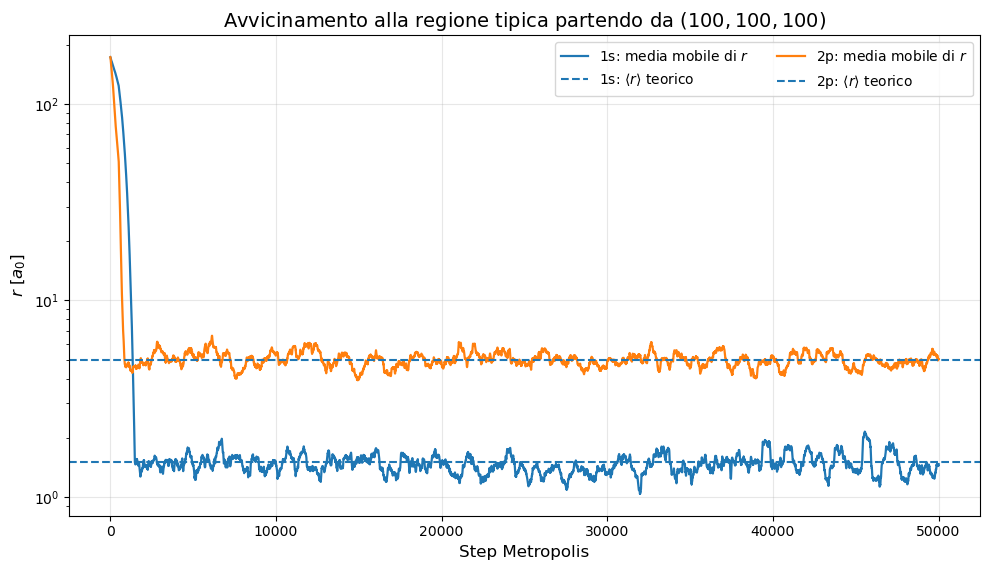

In [7]:
equilibration_files = {
    "1s": "equilibration_1s_far_uniform.txt",
    "2p": "equilibration_2p_far_uniform.txt",
}

equilibration_data = {state: read_equilibration(filename) for state, filename in equilibration_files.items()}

fig, ax = plt.subplots(figsize=(10, 5.8))

for state, exact_value in [("1s", 1.5), ("2p", 5.0)]:
    data = equilibration_data[state].copy()
    data["rolling_r"] = data["r"].rolling(window=500, min_periods=1).mean()

    ax.plot(data["step"], data["rolling_r"], label=rf"{state}: media mobile di $r$")
    ax.axhline(exact_value, linestyle="--", linewidth=1.5, label=rf"{state}: $\langle r\rangle$ teorico")

ax.set_yscale("log")
ax.set_title(r"Avvicinamento alla regione tipica partendo da $(100,100,100)$")
ax.set_xlabel("Step Metropolis")
ax.set_ylabel(r"$r$ [$a_0$]")
ax.legend(frameon=True, ncol=2)
fig.tight_layout()
plt.show()

In questo caso viene mostrata la media mobile e non quella progressiva, in quanto quest'ultima sarebbe influenzata dal punto di partenza.

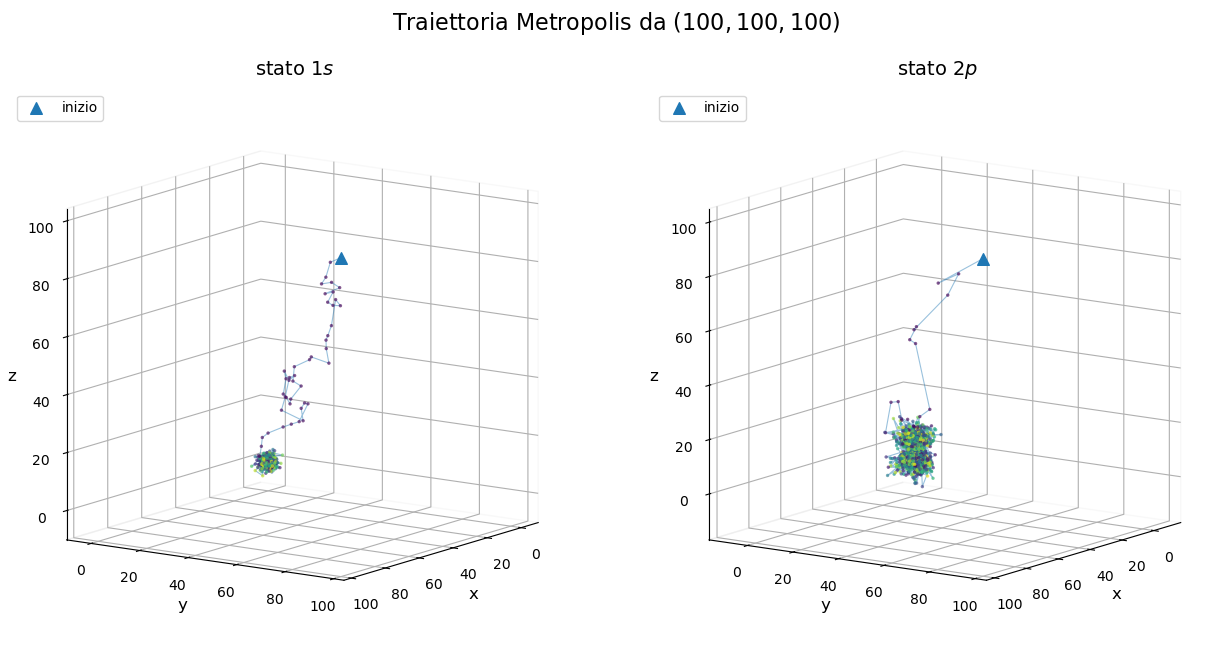

In [8]:
def downsample_by_index(data, max_points=2500):
    if len(data) <= max_points:
        return data.copy()
    indices = np.linspace(0, len(data) - 1, max_points).astype(int)
    return data.iloc[indices].copy()


def polish_far_axes(ax, data, title):
    max_coordinate = max(data[["x", "y", "z"]].max().max(), 1.0)
    min_coordinate = min(data[["x", "y", "z"]].min().min(), 0.0)
    padding = 0.04 * (max_coordinate - min_coordinate)

    ax.set_xlim(min_coordinate - padding, max_coordinate + padding)
    ax.set_ylim(min_coordinate - padding, max_coordinate + padding)
    ax.set_zlim(min_coordinate - padding, max_coordinate + padding)
    ax.set_box_aspect((1, 1, 1))
    ax.set_proj_type("ortho")
    ax.view_init(elev=12, azim=35)
    ax.set_title(title, pad=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False


fig = plt.figure(figsize=(13, 6.5))

for i, state in enumerate(["1s", "2p"], start=1):
    ax = fig.add_subplot(1, 2, i, projection="3d")
    data = downsample_by_index(equilibration_data[state], max_points=2200)

    sc = ax.scatter(
        data["x"], data["y"], data["z"],
        c=data["step"],
        cmap="viridis",
        s=6,
        alpha=0.65,
        linewidths=0,
        depthshade=False,
    )
    ax.plot(data["x"], data["y"], data["z"], linewidth=0.8, alpha=0.45)

    start = data.iloc[0]
    end = data.iloc[-1]
    ax.scatter(start["x"], start["y"], start["z"], s=70, marker="^", label="inizio")
    ax.legend(frameon=True, loc="upper left")

    polish_far_axes(ax, data, rf"stato ${state}$")

fig.suptitle(r"Traiettoria Metropolis da $(100,100,100)$", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


Partendo da $(100,100,100)$ il raggio iniziale è molto più grande della scala tipica degli orbitali. La catena si avvicina progressivamente alla zona in cui $|\Psi|^2$ è significativa; proprio per questo i primi passi non vanno usati per stimare gli osservabili. La fase di equilibrazione serve a eliminare la dipendenza artificiale dalla condizione iniziale.


## Numero di passi per blocco

Nel Metropolis le configurazioni consecutive sono correlate: ogni punto nasce dal precedente. Per questo motivo ogni blocco deve contenere un numero di passi abbastanza grande rispetto al tempo di autocorrelazione della catena. Se i blocchi fossero troppo corti, le medie di blocco sarebbero ancora fortemente correlate e l'incertezza statistica risulterebbe poco affidabile.

Nel codice sono stati usati $10^4$ passi per blocco e $100$ blocchi. Per questo esercizio la scelta è ragionevole: le stime progressive si stabilizzano e risultano compatibili con i valori teorici entro le incertezze.

## Conclusioni

Le simulazioni Metropolis riproducono i valori attesi teorici

$$
\langle r \rangle_{1s} = 1.5a_0,
\qquad
\langle r \rangle_{2p} = 5a_0.
$$

La proposta uniforme e quella gaussiana portano allo stesso risultato entro le incertezze statistiche: cambiano il modo in cui la catena esplora lo spazio, ma non la distribuzione stazionaria finale. Gli scatter plot confermano qualitativamente la forma degli orbitali, con simmetria sferica per il $1s$ e struttura a due lobi per il $2p$.

La prova con partenza lontana dall'origine mostra infine che l'equilibrazione non è un dettaglio tecnico: senza scartare il transiente iniziale, la stima sarebbe contaminata dalla scelta arbitraria del punto di partenza.


In [9]:
trajectory_stride = 100

def lag_autocorrelation(x, lag=1):
    x = np.asarray(x)

    if lag >= len(x):
        return np.nan

    x0 = x[:-lag]
    x1 = x[lag:]

    return np.corrcoef(x0, x1)[0, 1]


autocorrelation_rows = []

for (state, proposal), data in trajectory_data.items():
    r = np.sqrt(data["x"]**2 + data["y"]**2 + data["z"]**2)

    corr_lag_1 = lag_autocorrelation(r, lag=1)
    corr_lag_2 = lag_autocorrelation(r, lag=2)
    corr_lag_5 = lag_autocorrelation(r, lag=5)

    autocorrelation_rows.append({
        "Stato": state,
        "Proposta": proposal,
        r"$C(100)$": corr_lag_1,
        r"$C(200)$": corr_lag_2,
        r"$C(500)$": corr_lag_5,
    })

autocorrelation_table = pd.DataFrame(autocorrelation_rows)
display(autocorrelation_table)

,Stato,Proposta,$C(100)$,$C(200)$,$C(500)$
0,1s,Uniforme,-0.000310,-0.001190,-0.009189
1,1s,Gaussiana,-0.009503,-0.009121,0.015326
2,2p,Uniforme,-0.004505,-0.011431,0.020125
3,2p,Gaussiana,0.014417,-0.016853,-0.005419
